# Stage-31 pz1 cap paste diagnostics

Focused checks for the 600 deg² Abacus Backlight paste validation. The goal is to understand why the cap-sim spectra do not sit on the Stage-31 theory curves, with emphasis on

- $g \times y$,
- $g \times \kappa_{\rm CMB}$,
- $g \times$ DES shear/source-bin-1 kappa.

Important comparison caveat: the quick validation notebook used total-particle-shell maps and low-$\ell$ replacement for `map_kappa_cmb`, `map_kappa_wl`, and `map_tau`. The current pz1 cap products shown here are halo-profile pasted maps only; no total-shell low-$\ell$ replacement has been applied.


In [1]:

import json
import math
import sys
from pathlib import Path

import h5py
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX')
SCRIPT_DIR = REPO / 'notebooks/xDESI/abacus_paste'
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

import stage31_pz1_backlight_validation as val

CONFIG = REPO / 'notebooks/xDESI/abacus_paste/stage31_pz1_cap600.selected.yaml'
OUT = REPO / 'data/xDESI/processed/abacus_backlight/stage31_pz1_cap600'
MAP_N1024 = OUT / 'maps/stage31_pz1_cap600/abacus_pasted_maps_pz1cap600_z0p30_0p62_logMgt11p0_nside1024.h5'
SIM_N1024 = OUT / 'measurements/sim_pz1_cap600_nside1024_lmax1024_nbin10_linear.h5'
CAP_THEORY_N1024 = OUT / 'theory/stage31_pz1_cap600_theory_for_data_pz1_cap600_nside1024_lmax1024_nbin10_linear.h5'
FULL_MEAS = REPO / 'data/xDESI/processed/multiprobe_namaster_true_nz/fast1024/xdesi_multiprobe_cls_cov_nside1024_lmax1024_nbin10_linear.h5'
BESTFIT_VEC = REPO / 'notebooks/xDESI/survey_measure/outputs/godmax_multiprobe_fast1024_true_nz_hmc_stage31_multigpu/stage31_hmc_400x16_v1/combined/bestfit_theory_data_vector_stage31_multigpu.npz'
MAP_PRODUCT = REPO / 'data/xDESI/processed/multiprobe_namaster_true_nz/fast1024/xdesi_multiprobe_maps_nside1024_lmax1024_nbin10_linear.h5'

for p in [MAP_N1024, SIM_N1024, CAP_THEORY_N1024, FULL_MEAS, BESTFIT_VEC, MAP_PRODUCT]:
    print(p, 'exists=', p.exists())


/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/abacus_backlight/stage31_pz1_cap600/maps/stage31_pz1_cap600/abacus_pasted_maps_pz1cap600_z0p30_0p62_logMgt11p0_nside1024.h5 exists= True
/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/abacus_backlight/stage31_pz1_cap600/measurements/sim_pz1_cap600_nside1024_lmax1024_nbin10_linear.h5 exists= True
/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/abacus_backlight/stage31_pz1_cap600/theory/stage31_pz1_cap600_theory_for_data_pz1_cap600_nside1024_lmax1024_nbin10_linear.h5 exists= True
/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster_true_nz/fast1024/xdesi_multiprobe_cls_cov_nside1024_lmax1024_nbin10_linear.h5 exists= True
/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI/survey_measure/outputs/godmax_multiprobe_fast1024_true_nz_hmc_stage31_multigpu/stage31_hmc_400x16_v1/combined/bestfit_theory_data_vector_stage31_multigpu.npz exists= True
/mnt/ceph/users/span

In [2]:

def decode(arr):
    return [x.decode() if isinstance(x, bytes) else str(x) for x in arr]

def read_sim(path):
    out = {}
    with h5py.File(path, 'r') as h5:
        names = decode(h5['joint/spectrum_names'][:])
        ell = h5['joint/ell'][:]
        meta = json.loads(h5.attrs['map_metadata_json'])
        field_meta = json.loads(h5['fields'].attrs['metadata_json'])
        for name in names:
            out[name] = h5[f'spectra/{name}/cl'][:]
    return ell, out, meta, field_meta

def read_cap_theory(path):
    with h5py.File(path, 'r') as h5:
        names = decode(h5['windowed/spectrum_names'][:])
        ell = h5['windowed/ell'][:]
        n = len(ell)
        full = h5['windowed/full_hod_floor10p5'][:]
        resolved = h5['windowed/resolved_log10Mgt11'][:]
        delta = h5['windowed/unresolved_delta'][:]
    out = {}
    for i, name in enumerate(names):
        sl = slice(i*n, (i+1)*n)
        out[name] = {'full': full[sl], 'resolved': resolved[sl], 'delta': delta[sl]}
    return ell, out

def read_full_data_and_bestfit(meas_path, bestfit_path):
    with h5py.File(meas_path, 'r') as h5:
        names = decode(h5['joint/spectrum_names'][:])
        ell = h5['joint/ell'][:]
        starts = h5['joint/slice_start'][:].astype(int)
        stops = h5['joint/slice_stop'][:].astype(int)
        data = h5['joint/data_vector'][:]
        cov = h5['joint/cov'][:]
    with np.load(bestfit_path, allow_pickle=True) as npz:
        best_names = decode(npz['spectrum_names'])
        best = npz['theory_vector']
    assert names == best_names
    out = {}
    for name, start, stop in zip(names, starts, stops):
        err = np.sqrt(np.clip(np.diag(cov[start:stop, start:stop]), 0, np.inf))
        out[name] = {'data': data[start:stop], 'err': err, 'bestfit': best[start:stop]}
    return ell, out

def dell(ell, cl):
    ell = np.asarray(ell, dtype=float)
    return ell * (ell + 1.0) / (2.0 * np.pi) * np.asarray(cl, dtype=float)

ell_sim, sim, sim_meta, field_meta = read_sim(SIM_N1024)
ell_th, cap_theory = read_cap_theory(CAP_THEORY_N1024)
ell_full, full_data = read_full_data_and_bestfit(FULL_MEAS, BESTFIT_VEC)
print('sim spectra:', list(sim))
print('skipped:', sim_meta['spectra_skipped_missing_sim_fields'])
print('ell:', ell_sim)
assert np.allclose(ell_sim, ell_th)
assert np.allclose(ell_sim, ell_full)


sim spectra: ['desi_g_auto_pz1', 'desi_g_act_y_pz1', 'desi_g_des_shear_E_pz1_tomo1', 'desi_g_act_kappa_pz1', 'desi_g_tau_pz1']
skipped: ['desi_g_des_shear_E_pz1_tomo2', 'desi_g_des_shear_E_pz1_tomo3', 'desi_g_des_shear_E_pz1_tomo4', 'desi_pi_act_T_pz1']
ell: [ 58.5 160.5 262.5 364.  465.5 567.5 669.  770.5 872.5 974. ]


In [3]:

focus = [
    ('desi_g_act_y_pz1', r'$g\times y$'),
    ('desi_g_act_kappa_pz1', r'$g\times\kappa_{\rm CMB}$'),
    ('desi_g_des_shear_E_pz1_tomo1', r'$g\times$ shear E tomo 1'),
]

rows = []
for name, label in focus:
    if name not in sim or name not in cap_theory:
        continue
    s = sim[name]
    full = cap_theory[name]['full']
    res = cap_theory[name]['resolved']
    best = full_data[name]['bestfit']
    rows.append({
        'spectrum': name,
        'median sim / cap full-HOD theory': float(np.nanmedian(s / full)),
        'median sim / cap resolved theory': float(np.nanmedian(s / res)),
        'median resolved / full theory': float(np.nanmedian(res / full)),
        'median sim / full-footprint bestfit vector': float(np.nanmedian(s / best)),
    })
summary = pd.DataFrame(rows)
display(summary)


,spectrum,median sim / cap full-HOD theory,median sim / cap resolved theory,median resolved / full theory,median sim / full-footprint bestfit vector
0,desi_g_act_y_pz1,2.065936,1.756488,1.174952,2.061373
1,desi_g_act_kappa_pz1,1.626432,1.390236,1.169947,1.620936
2,desi_g_des_shear_E_pz1_tomo1,1.054275,0.910601,1.152473,1.053109


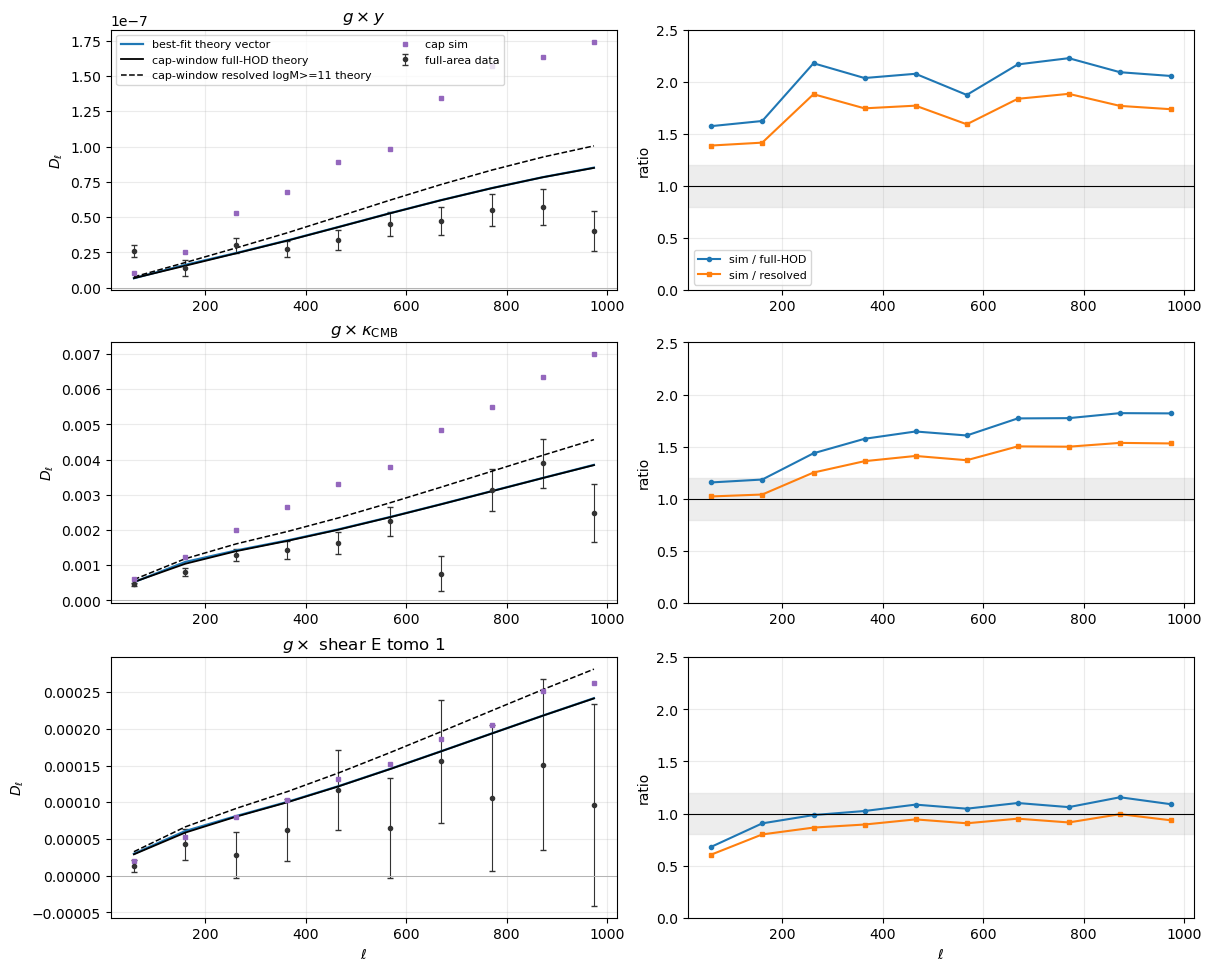

In [4]:

fig, axes = plt.subplots(len(focus), 2, figsize=(12, 3.2 * len(focus)), constrained_layout=True)
for i, (name, label) in enumerate(focus):
    ax, rax = axes[i]
    if name not in sim:
        ax.set_axis_off(); rax.set_axis_off(); continue
    ax.errorbar(ell_full, dell(ell_full, full_data[name]['data']), yerr=dell(ell_full, full_data[name]['err']), fmt='o', ms=3, lw=0.8, capsize=2, color='0.2', label='full-area data')
    ax.plot(ell_full, dell(ell_full, full_data[name]['bestfit']), color='tab:blue', lw=1.6, label='best-fit theory vector')
    ax.plot(ell_th, dell(ell_th, cap_theory[name]['full']), color='k', lw=1.3, ls='-', label='cap-window full-HOD theory')
    ax.plot(ell_th, dell(ell_th, cap_theory[name]['resolved']), color='k', lw=1.1, ls='--', label='cap-window resolved logM>=11 theory')
    ax.plot(ell_sim, dell(ell_sim, sim[name]), 's', ms=3.5, color='tab:purple', label='cap sim')
    ax.axhline(0, color='0.7', lw=0.7)
    ax.set_title(label)
    ax.set_ylabel(r'$D_\ell$')
    ax.grid(alpha=0.25)
    if i == 0:
        ax.legend(fontsize=8, ncol=2)
    rax.plot(ell_sim, sim[name] / cap_theory[name]['full'], 'o-', ms=3, label='sim / full-HOD')
    rax.plot(ell_sim, sim[name] / cap_theory[name]['resolved'], 's-', ms=3, label='sim / resolved')
    rax.axhline(1, color='k', lw=0.8)
    rax.axhspan(0.8, 1.2, color='0.85', alpha=0.45)
    rax.set_ylim(0, 2.5)
    rax.set_ylabel('ratio')
    rax.grid(alpha=0.25)
    if i == 0:
        rax.legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel(r'$\ell$')
plt.show()


,nonzero_union_pixels,"corr(kappa_cmb, kappa_wl)",rms(kappa_cmb),rms(kappa_wl),rms ratio cmb/wl,median pixel ratio cmb/wl
0,213523,0.831607,0.033673,0.001608,20.947133,22.995951


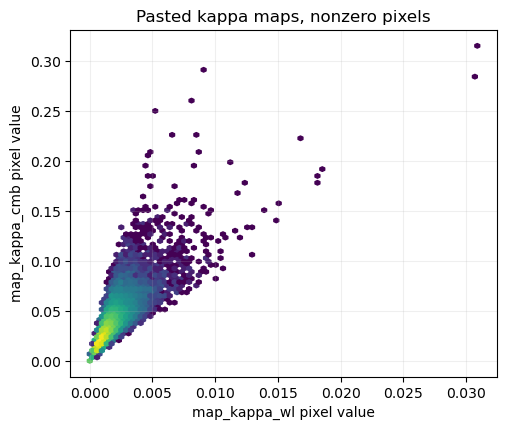

In [5]:

# Map-level checks: are CMB-kappa and WL-kappa maps distinct, and how large are they?
with h5py.File(MAP_N1024, 'r') as h5:
    maps = {key: h5[f'maps/{key}'][:] for key in h5['maps']}
    map_attrs = dict(h5.attrs)

kc = maps['map_kappa_cmb'].astype('f8')
kw = maps['map_kappa_wl'].astype('f8')
sel = (kc != 0) | (kw != 0)
map_rows = [{
    'nonzero_union_pixels': int(np.count_nonzero(sel)),
    'corr(kappa_cmb, kappa_wl)': float(np.corrcoef(kc[sel], kw[sel])[0, 1]),
    'rms(kappa_cmb)': float(np.sqrt(np.mean(kc[sel]**2))),
    'rms(kappa_wl)': float(np.sqrt(np.mean(kw[sel]**2))),
    'rms ratio cmb/wl': float(np.sqrt(np.mean(kc[sel]**2)) / np.sqrt(np.mean(kw[sel]**2))),
    'median pixel ratio cmb/wl': float(np.nanmedian(kc[sel] / np.where(kw[sel] != 0, kw[sel], np.nan))),
}]
display(pd.DataFrame(map_rows))

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4.5))
idx = np.flatnonzero(sel)
rng = np.random.default_rng(123)
if idx.size > 50000:
    idx = rng.choice(idx, size=50000, replace=False)
ax.hexbin(kw[idx], kc[idx], gridsize=80, bins='log', mincnt=1)
ax.set_xlabel('map_kappa_wl pixel value')
ax.set_ylabel('map_kappa_cmb pixel value')
ax.set_title('Pasted kappa maps, nonzero pixels')
ax.grid(alpha=0.2)
plt.show()


In [6]:

# Transfer and density checks.
transfer_rows = []
with h5py.File(MAP_PRODUCT, 'r') as h5:
    if 'transfer_functions/act_kappa_filter_baseline' in h5:
        f = h5['transfer_functions/act_kappa_filter_baseline'][:]
        for ell in [50, 100, 200, 500, 1000]:
            transfer_rows.append({'field': 'ACT kappa filter', 'ell': ell, 'value': float(np.interp(ell, f[:, 0], f[:, 1]))})
    if 'transfer_functions/act_y_gaussian_beam' in h5:
        y = h5['transfer_functions/act_y_gaussian_beam'][:]
        for ell in [50, 100, 200, 500, 1000]:
            transfer_rows.append({'field': 'ACT y Gaussian beam', 'ell': ell, 'value': float(y[min(ell, len(y)-1)])})
display(pd.DataFrame(transfer_rows))

gmeta = field_meta['g1']['metadata']
target_density = 167.86608969615435
area_deg2 = gmeta['area_sr'] * (180.0 / math.pi)**2
density_rows = [{
    'sim Ngal in mask': int(gmeta['n_gal']),
    'weighted mask area deg2': area_deg2,
    'sim density deg^-2': gmeta['n_gal'] / area_deg2,
    'target pz1 density deg^-2': target_density,
    'sim / target density': (gmeta['n_gal'] / area_deg2) / target_density,
    'shot noise': gmeta['shot_noise'],
}]
display(pd.DataFrame(density_rows))


,field,ell,value
0,ACT kappa filter,50,1.000000
1,ACT kappa filter,100,1.000000
2,ACT kappa filter,200,1.000000
3,ACT kappa filter,500,1.000000
4,ACT kappa filter,1000,1.000000
5,ACT y Gaussian beam,50,0.999950
6,ACT y Gaussian beam,100,0.999803
7,ACT y Gaussian beam,200,0.999215
8,ACT y Gaussian beam,500,0.995119
9,ACT y Gaussian beam,1000,0.980638


,sim Ngal in mask,weighted mask area deg2,sim density deg^-2,target pz1 density deg^-2,sim / target density,shot noise
0,66589,630.150437,105.671592,167.86609,0.629499,0.000003


## Reading the diagnostics

The main checks to interpret are:

1. **Resolved-vs-full HOD:** the current cap catalog uses `log10M >= 11`, while the analytic HOD floor is `log10M = 10.5`. The resolved/full theory ratio is not enough by itself to explain all mismatches, but it matters.

2. **Galaxy density and HOD selection:** the pasted pz1 density in the mask is about 106 deg$^{-2}$, while the target pz1 density is about 168 deg$^{-2}$. A lower-density HOD sample can be more biased, raising cross-correlations even if the parameters are otherwise the same.

3. **Kappa low-ell / shell content:** unlike `abacus_quick_paste_validation.ipynb`, these maps do not include total-particle-shell low-$\ell$ replacement for `map_kappa_cmb`, `map_kappa_wl`, or `map_tau`. That is especially relevant for lensing. The quick validation explicitly replaced low-$\ell$ modes up to `L=256` before comparing kappa spectra.

4. **ACT transfer functions:** the ACT kappa transfer stored in the Stage-31 map product is unity at the band centers tested here, and the y beam is only a few percent at $\ell \lesssim 1000$. Those are not large enough to explain order-unity differences.

5. **Why shear can look better than CMB kappa:** DES source-bin-1 shear uses the pasted `map_kappa_wl` field and no ACT-kappa-specific reconstruction convention. The current `map_kappa_cmb` is a different lensing kernel and is more sensitive to missing large-scale/total-shell mass content.

Next high-value tests:

- regenerate the pz1 cap maps with total-shell low-$\ell$ replacement for `map_kappa_cmb` and `map_kappa_wl`, matching the quick-validation workflow;
- fix the HOD/nbar mismatch before treating amplitudes as final;
- rerun the paste after the multi-source-bin and CMB-kernel setup patches, then remeasure the same ratios.
